# Implementing Logistic regression from scratch

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression

In [3]:
def sigmoid(z):
    return 1/(1+(np.exp(-z)))

In [4]:
# to get the value between 0 and 1, we will take y_hat and pass it through the sigmoid function.
# first lets just do it for a small dataset, then we will use numpy vectors to do it on a larger dataset.

# creating a dataset with cgpa and placement (0 for me and 1 for ppl who are place 🤡)
df = pd.DataFrame({'cgpa': [8.5,6.2,7.9,5.2, 6.8,7.2,6.4], 'placed': [1,0,1,0,1,1,0]})
df

,cgpa,placed
0,8.5,1
1,6.2,0
2,7.9,1
3,5.2,0
4,6.8,1
5,7.2,1
6,6.4,0


In [5]:
# since we only have one feature, we can use y = wx + b
w = 1
b = 0
x = df.iloc[:,0]
y = df.iloc[:,-1]
z = np.dot(w, x) + b
y_hat = sigmoid(z)
print("Z: ", z)
print("y_hat: ", y_hat)
print("x", x.head())

Z:  [8.5 6.2 7.9 5.2 6.8 7.2 6.4]
y_hat:  [0.99979657 0.99797468 0.99962939 0.9945137  0.99888746 0.99925397
 0.9983412 ]
x 0    8.5
1    6.2
2    7.9
3    5.2
4    6.8
Name: cgpa, dtype: float64


In [6]:
# computing cost of the current model:
m = np.shape(x)[0]
def compute_cost (y,y_hat):
    # `J = -(1/m) Σ [y log(ŷ) + (1-y) log(1-ŷ)]`
    return -(1/m) * np.sum((y*np.log(y_hat)) + ((1-y) * np.log(1-y_hat)))

In [7]:
def compute_gradient(X,y,w,b,m):
    # to compute gradient, we need to figure out PDE of w and b w.r.t J(cost function)
    y_hat = sigmoid(np.dot(w,X)+b) # for multi features -> np.dot(X,w)+b 
    # X = (m , n) & w = (n), and their dot product produces: (m,) i.e. one prediction per sample.
    # print("y_hat : ", y_hat)
    # print("y", y)
    # print("x", x)
    # print("m" , m)
    dw = (1/m) * np.sum((y_hat - y)*X)
    db = (1/m) * np.sum(y_hat-y)
    return dw, db

In [8]:
dw, db = compute_gradient(x,y,1,1,np.shape(x)[0])
dw

np.float64(2.539208255620453)

In [9]:
def gradient_descent(X,y,w,b,compute_gradient):

    #learning rate:
    lr = 0.5
    losses = []
    m = np.shape(X)[0]
    for i in range(0,3000):
        dw,db = compute_gradient(X,y,w,b,m)
        losses.append(compute_cost(y, sigmoid(w*X + b)))
        w = w - lr*dw
        b = b - lr*db

    return w,b, losses

In [10]:
w,b, losses = gradient_descent(x,y,1,1,compute_gradient)


In [11]:
print(w)
print(b)

4.433169763796793
-29.334792474428113


In [12]:
z = w * x + b
print(z)
y_pred = sigmoid(z)
y_pred

0    8.347151
1   -1.849140
2    5.687249
3   -6.282310
4    0.810762
5    2.584030
6   -0.962506
Name: cgpa, dtype: float64


0    0.999763
1    0.135974
2    0.996623
3    0.001866
4    0.692272
5    0.929827
6    0.276377
Name: cgpa, dtype: float64

In [13]:
y_class = (y_pred >= 0.5).astype(int)
y_class

0    1
1    0
2    1
3    0
4    1
5    1
6    0
Name: cgpa, dtype: int64

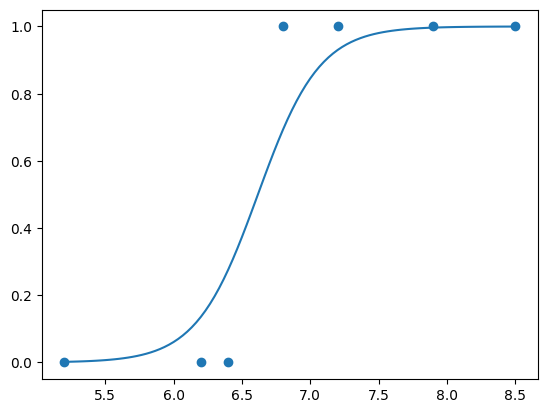

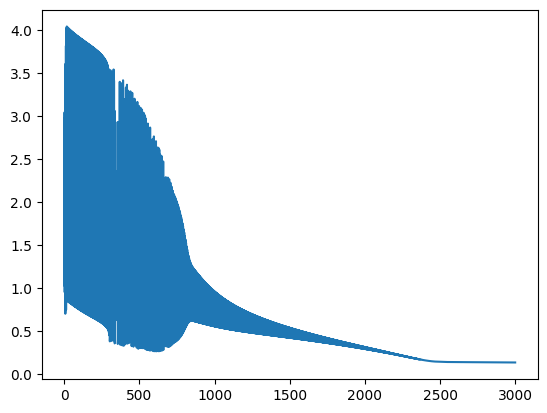

In [14]:
x_vals = np.linspace(min(x), max(x), 100)
y_vals = sigmoid(w*x_vals + b)
plt.scatter(x,y)
plt.plot(x_vals,y_vals)
plt.show()
plt.plot(losses)

### Comparing Sklearn's logistic with my logistic regression 🤡

In [15]:
model = LogisticRegression(penalty=None, solver='sag')

X_sklearn = x.values.reshape(-1,1)
y_sklearn = y.values

model.fit(X_sklearn, y_sklearn)

w_sklearn = model.coef_[0][0]
b_sklearn = model.intercept_[0]

print("My model:", w, b)
print("Sklearn model:", w_sklearn, b_sklearn)

My model: 4.433169763796793 -29.334792474428113
Sklearn model: 0.3513161043245133 -1.9238924156641144


c:\Users\sangh\anaconda3\envs\ML\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\sangh\anaconda3\envs\ML\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [18]:
x_vals = np.linspace(min(x), max(x), 200)
y_vals_my = sigmoid(w * x_vals + b)
y_vals_sklearn = sigmoid(w_sklearn * x_vals + b_sklearn)


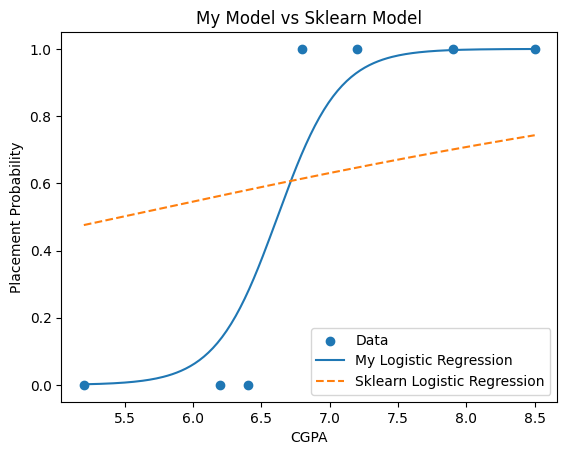

In [19]:
plt.scatter(x, y, label="Data")

plt.plot(x_vals, y_vals_my, label="My Logistic Regression")
plt.plot(x_vals, y_vals_sklearn, linestyle='dashed', label="Sklearn Logistic Regression")

plt.legend()
plt.xlabel("CGPA")
plt.ylabel("Placement Probability")
plt.title("My Model vs Sklearn Model")

plt.show()

In [20]:
boundary_my = -b / w
boundary_sklearn = -b_sklearn / w_sklearn

print("My decision boundary:", boundary_my)
print("Sklearn boundary:", boundary_sklearn)

My decision boundary: 6.617114623939936
Sklearn boundary: 5.476243166715183
